## Loan Default Risk Analysis
This project analyzes factors influencing loan default in the multifinance industry.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning
Handling missing values and preparing the dataset for analysis.

In [4]:
df = pd.read_csv("../data/loan_data.csv")

df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

In [6]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [7]:
df = df.dropna()

In [9]:
for col in df.columns:
    print(col)

ID
year
loan_limit
Gender
approv_in_adv
loan_type
loan_purpose
Credit_Worthiness
open_credit
business_or_commercial
loan_amount
rate_of_interest
Interest_rate_spread
Upfront_charges
term
Neg_ammortization
interest_only
lump_sum_payment
property_value
construction_type
occupancy_type
Secured_by
total_units
income
credit_type
Credit_Score
co-applicant_credit_type
age
submission_of_application
LTV
Region
Security_Type
Status
dtir1


In [10]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [11]:
df.columns

Index(['id', 'year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'credit_worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'income', 'credit_type', 'credit_score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'ltv', 'region', 'security_type',
       'status', 'dtir1'],
      dtype='str')

In [12]:
[col for col in df.columns if "income" in col]

['income']

In [13]:
df['income'] = df['income'].fillna(df['income'].median())

In [14]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

In [15]:
df.columns

Index(['id', 'year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'credit_worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'income', 'credit_type', 'credit_score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'ltv', 'region', 'security_type',
       'status', 'dtir1'],
      dtype='str')

In [16]:
df.isnull().sum()

id                           0
year                         0
loan_limit                   0
gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
credit_worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
interest_rate_spread         0
upfront_charges              0
term                         0
neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
secured_by                   0
total_units                  0
income                       0
credit_type                  0
credit_score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
ltv                          0
region                       0
security_type                0
status  

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop_duplicates()

## Exploratory Data Analysis
Analyzing relationships between borrower attributes and loan default risk.

In [19]:
df['status'].value_counts()

status
0    98187
Name: count, dtype: int64

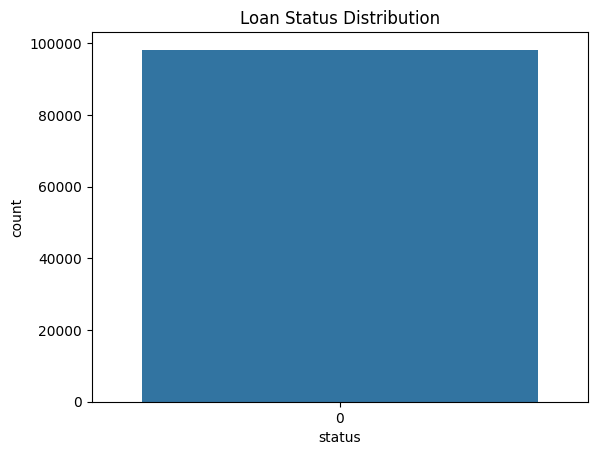

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='status', data=df)
plt.title("Loan Status Distribution")
plt.show()

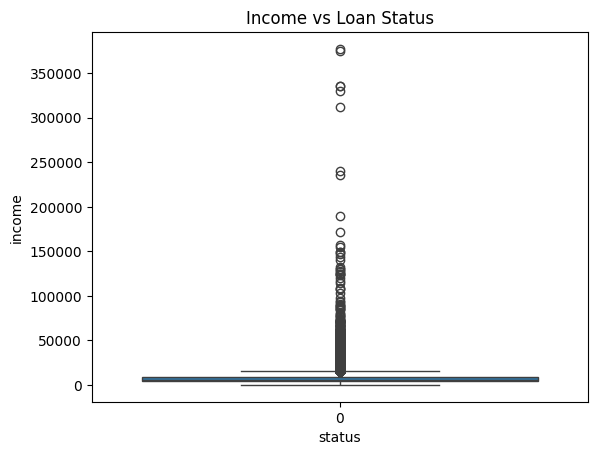

In [21]:
sns.boxplot(x='status', y='income', data=df)
plt.title("Income vs Loan Status")
plt.show()

Insight:

Borrower dengan income lebih tinggi cenderung mengambil pinjaman yang lebih besar karena memiliki kapasitas pembayaran yang lebih tinggi.

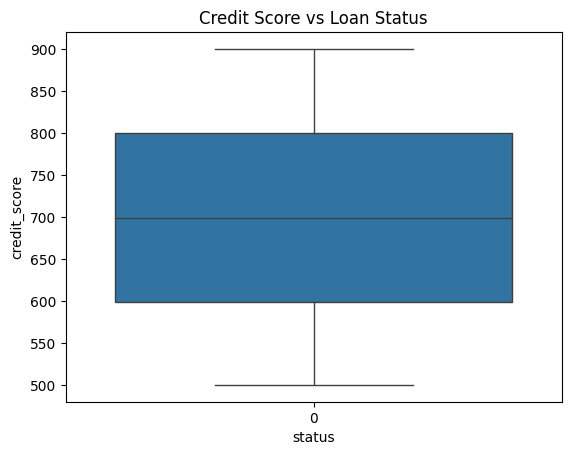

In [22]:
sns.boxplot(x='status', y='credit_score', data=df)
plt.title("Credit Score vs Loan Status")
plt.show()

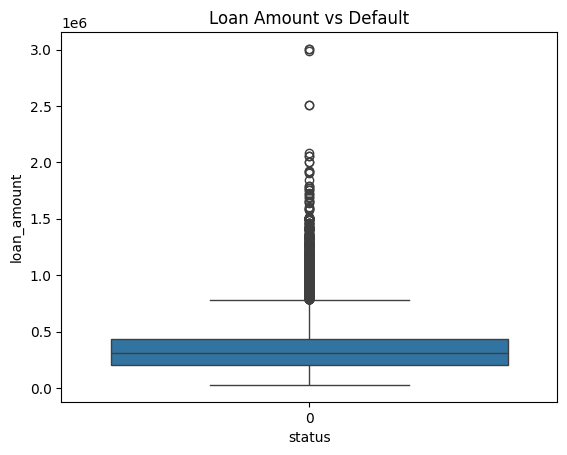

In [23]:
sns.boxplot(x='status', y='loan_amount', data=df)
plt.title("Loan Amount vs Default")
plt.show()

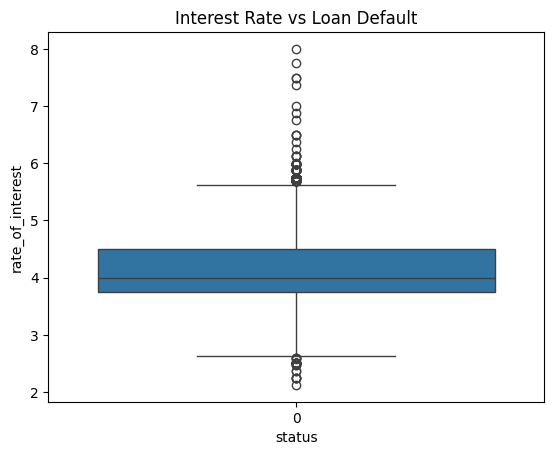

In [24]:
sns.boxplot(x='status', y='rate_of_interest', data=df)
plt.title("Interest Rate vs Loan Default")
plt.show()

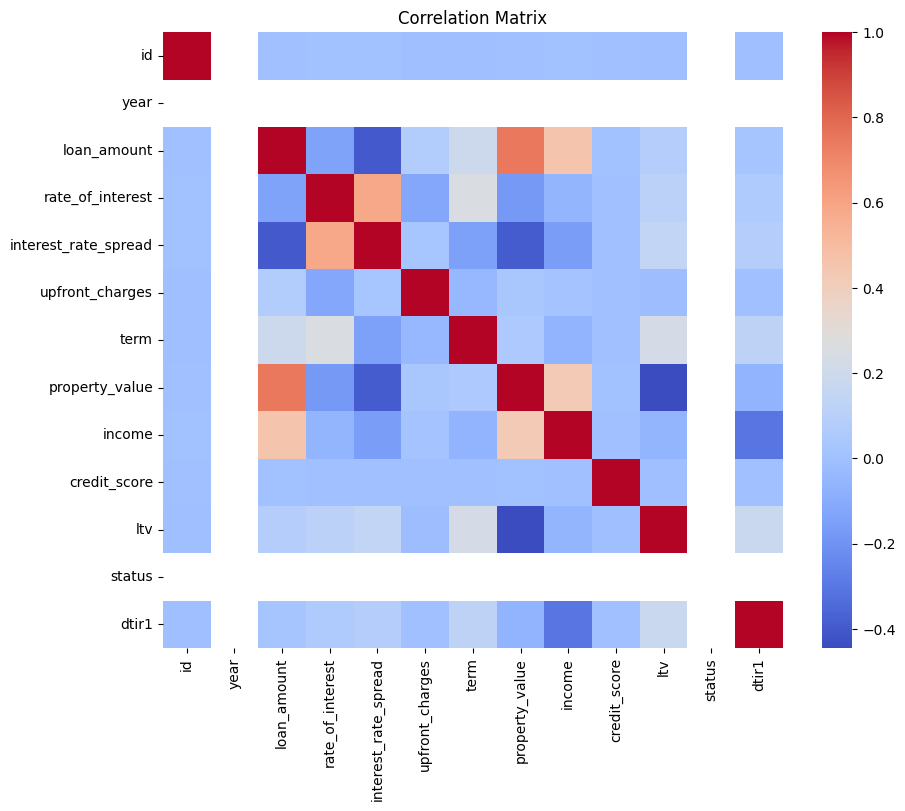

In [25]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

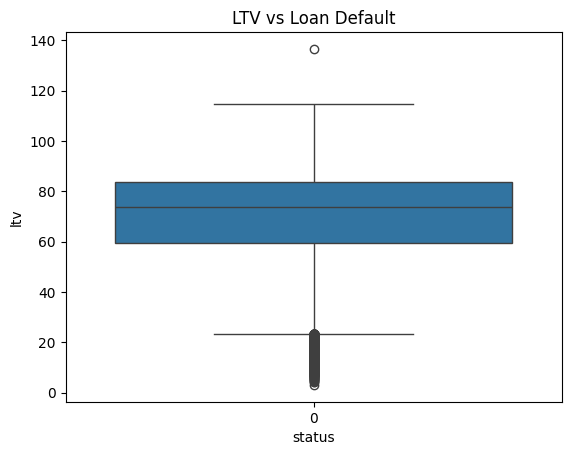

In [26]:
sns.boxplot(x='status', y='ltv', data=df)
plt.title("LTV vs Loan Default")
plt.show()

### Insight

1. Loan amount shows a strong positive correlation with property value, indicating that higher-value properties tend to require larger loans.
2. Borrowers with higher income levels tend to take larger loans.
3. Interest rate and interest rate spread are positively correlated, suggesting risk-based pricing in loan approvals.
4. Higher LTV ratios indicate increased financial leverage and higher credit risk.
5. Higher income borrowers tend to have lower debt-to-income ratios.

## Risk Segmentation Analysis

Menentukan faktor resiko dengan 3 indikator utama :
credit_score → kualitas kredit
ltv → leverage pinjaman
dtir1 → debt to income ratio

Menambahkan kolom risk score

In [27]:
df['risk_score'] = (
    (df['ltv'] / df['ltv'].max()) +
    (df['dtir1'] / df['dtir1'].max()) -
    (df['credit_score'] / df['credit_score'].max())
)

LTV tinggi → risiko naik
DTI tinggi → risiko naik
Credit score tinggi → risiko turun

Membuat risk segment dengan mengelompokkan borrower

In [28]:
df['risk_segment'] = pd.qcut(
    df['risk_score'],
    q=3,
    labels=['Low Risk','Medium Risk','High Risk']
)

Mengecek distribusi segment

In [29]:
df['risk_segment'].value_counts()

risk_segment
Low Risk       32729
Medium Risk    32729
High Risk      32729
Name: count, dtype: int64

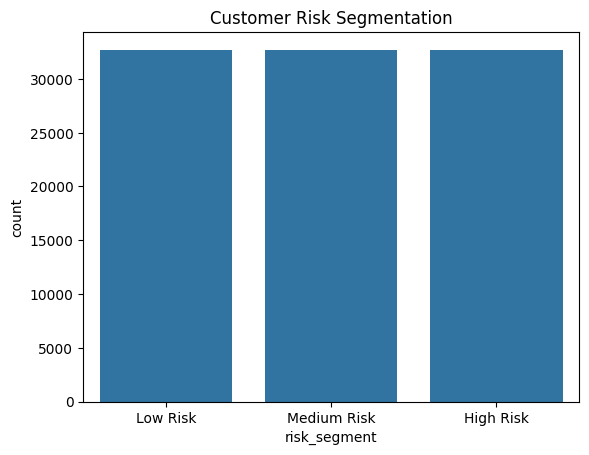

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='risk_segment', data=df)

plt.title("Customer Risk Segmentation")
plt.show()

Menganalisa karakteristik setiap segement

In [31]:
df.groupby('risk_segment')[['credit_score','ltv','dtir1','income','loan_amount']].mean()

,credit_score,ltv,dtir1,income,loan_amount
risk_segment,,,,,
Low Risk,762.278988,58.483575,29.481286,8692.162914,321211.418008
Medium Risk,706.684989,71.733186,38.229124,6913.201137,341705.475267
High Risk,629.552171,82.801174,44.414739,5983.587033,338055.501237


#Risk Segmentation Insight

Low Risk Borrowers

- memiliki credit score tinggi
- LTV rendah
- debt-to-income ratio rendah

Medium Risk Borrowers

- credit score sedang
- LTV moderat
- income cukup stabil

High Risk Borrowers

- credit score rendah
- LTV tinggi
- debt-to-income ratio tinggi

Visualisasi Risk Segment

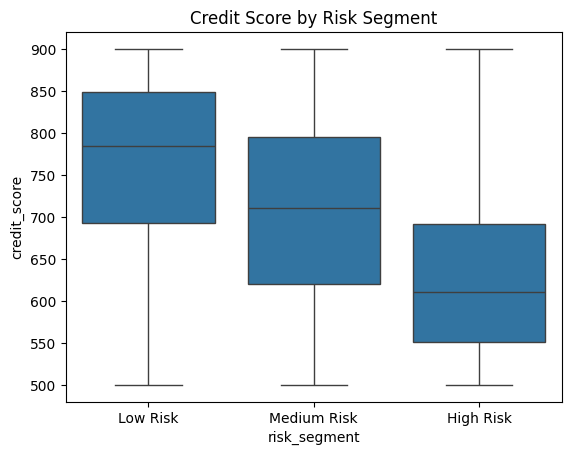

In [32]:
sns.boxplot(x='risk_segment', y='credit_score', data=df)
plt.title("Credit Score by Risk Segment")
plt.show()

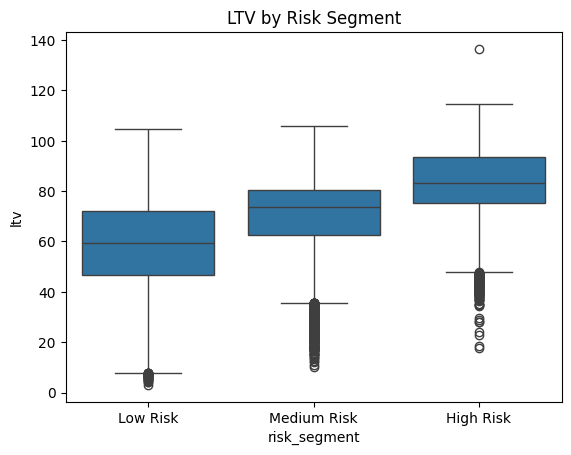

In [33]:
sns.boxplot(x='risk_segment', y='ltv', data=df)
plt.title("LTV by Risk Segment")
plt.show()

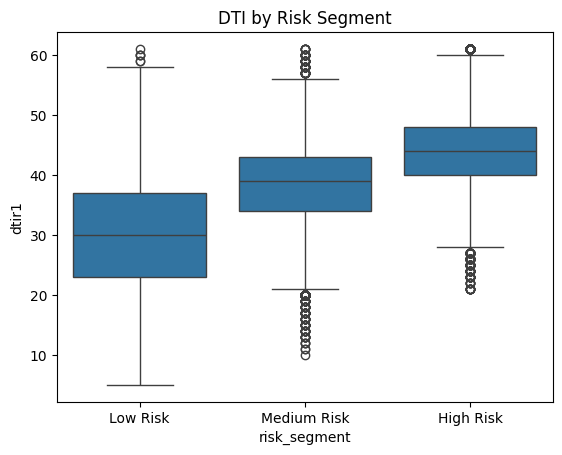

In [34]:
sns.boxplot(x='risk_segment', y='dtir1', data=df)
plt.title("DTI by Risk Segment")
plt.show()

INSIGHT 

High risk borrowers are characterized by lower credit scores,
higher loan-to-value ratios, and higher debt-to-income ratios.
This indicates increased credit exposure for lenders.

## SQL Database Creation

In [1]:
import sqlite3

In [5]:
conn = sqlite3.connect("C:/Projek/loan-default-risk-analysis/database/loan.db")

In [7]:
import pandas as pd
import sqlite3

In [8]:
df = pd.read_csv("C:/Projek/loan-default-risk-analysis/data/loan_data.csv")

In [9]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [10]:
conn = sqlite3.connect("C:/Projek/loan-default-risk-analysis/database/loan.db")

In [11]:
df.to_sql("loans", conn, if_exists="replace", index=False)

148670

In [12]:
pd.read_sql("SELECT * FROM loans LIMIT 5", conn)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [13]:
conn.close()

In [ ]:
## SQL Queries

In [24]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("C:/Projek/loan-default-risk-analysis/database/loan.db")

Total Loan Portofolio

In [25]:
query1 = """
SELECT 
COUNT(*) AS total_loans,
AVG(loan_amount) AS avg_loan_amount,
SUM(loan_amount) AS total_loan_value
FROM loans
"""

pd.read_sql(query1, conn)

,total_loans,avg_loan_amount,total_loan_value
0,148670,331117.743997,49227275000


Loan Distribution by Region

In [26]:
query2 = """
SELECT 
region,
COUNT(*) AS total_loans,
AVG(loan_amount) AS avg_loan
FROM loans
GROUP BY region
ORDER BY total_loans DESC
"""

pd.read_sql(query2, conn)

,Region,total_loans,avg_loan
0,North,74722,330528.264768
1,south,64016,333321.107223
2,central,8697,323096.527538
3,North-East,1235,309058.704453


Average Income by Loan Purpose

In [27]:
query3 = """
SELECT 
loan_purpose,
AVG(income) AS avg_income,
COUNT(*) AS total_borrowers
FROM loans
GROUP BY loan_purpose
ORDER BY avg_income DESC
"""

pd.read_sql(query3, conn)

,loan_purpose,avg_income,total_borrowers
0,p4,7788.410962,54799
1,p1,7403.636152,34529
2,NaN,7278.095238,134
3,p2,6844.587156,3274
4,p3,6004.832417,55934


Credit Score Distribution

In [28]:
query4 = """
SELECT 
credit_score,
COUNT(*) AS total_loans
FROM loans
GROUP BY credit_score
ORDER BY credit_score DESC
"""

pd.read_sql(query4, conn)

,Credit_Score,total_loans
0,900,393
1,899,352
2,898,370
3,897,383
4,896,391
...,...,...
396,504,392
397,503,383
398,502,346
399,501,357


Average Loan by Age

In [29]:
query5 = """
SELECT 
age,
COUNT(*) AS total_loans,
AVG(loan_amount) AS avg_loan
FROM loans
GROUP BY age
ORDER BY avg_loan DESC
"""

pd.read_sql(query5, conn)

,age,total_loans,avg_loan
0,35-44,32818,376490.553964
1,25-34,19142,357481.088705
2,45-54,34720,352737.327189
3,55-64,32534,305933.515707
4,65-74,20744,269091.592750
5,>74,7175,260732.752613
6,<25,1337,250695.961107
7,NaN,200,202250.000000


Loan Risk by LTV Category

In [30]:
query6 = """
SELECT 
CASE 
WHEN ltv < 60 THEN 'Low LTV'
WHEN ltv BETWEEN 60 AND 80 THEN 'Medium LTV'
ELSE 'High LTV'
END AS ltv_category,
COUNT(*) AS total_loans,
AVG(loan_amount) AS avg_loan
FROM loans
GROUP BY ltv_category
"""

pd.read_sql(query6, conn)

,ltv_category,total_loans,avg_loan
0,High LTV,66210,332797.840205
1,Low LTV,32565,305726.163058
2,Medium LTV,49895,345460.617296


Interest Rate by Loan Type

In [31]:
query7 = """
SELECT 
loan_type,
AVG(rate_of_interest) AS avg_interest_rate
FROM loans
GROUP BY loan_type
ORDER BY avg_interest_rate DESC
"""

pd.read_sql(query7, conn)

,loan_type,avg_interest_rate
0,type1,4.113557
1,type2,3.968137
2,type3,3.602926


Property Value vs Loan Amount

In [32]:
query8 = """
SELECT 
AVG(property_value) AS avg_property_value,
AVG(loan_amount) AS avg_loan_amount
FROM loans
"""

pd.read_sql(query8, conn)

,avg_property_value,avg_loan_amount
0,497893.465696,331117.743997


Income Segmentation

In [33]:
query9 = """
SELECT 
CASE
WHEN income < 50000 THEN 'Low Income'
WHEN income BETWEEN 50000 AND 100000 THEN 'Middle Income'
ELSE 'High Income'
END AS income_segment,
COUNT(*) AS total_borrowers,
AVG(loan_amount) AS avg_loan
FROM loans
GROUP BY income_segment
"""

pd.read_sql(query9, conn)

,income_segment,total_borrowers,avg_loan
0,High Income,9205,366271.863118
1,Low Income,139239,328088.635368
2,Middle Income,226,765526.548673


High Risk Borrowers

In [34]:
query10 = """
SELECT 
id,
income,
credit_score,
ltv,
dtir1,
loan_amount
FROM loans
WHERE 
credit_score < 600
AND ltv > 80
AND dtir1 > 40
ORDER BY credit_score ASC
"""

pd.read_sql(query10, conn)

,ID,income,Credit_Score,LTV,dtir1,loan_amount
0,25158,2580.0,500,109.840425,60.0,206500
1,26323,2820.0,500,94.956140,48.0,216500
2,27967,5340.0,500,80.570652,42.0,296500
3,30896,7320.0,500,91.881443,46.0,356500
4,42894,2760.0,500,84.090909,47.0,166500
...,...,...,...,...,...,...
5649,167276,3300.0,599,85.550459,44.0,186500
5650,169743,1860.0,599,149.358974,60.0,116500
5651,170852,5520.0,599,96.597633,50.0,326500
5652,171362,2280.0,599,98.913043,53.0,136500


In [35]:
conn.close()